## Paso 1 · Contrastes conductuales

Tres marcadores conductuales separan el gasto hedónico del utilitario:
concentración nocturna, sesgo de fin de semana y frecuencia de montos
redondos, este último como proxy de compra deliberada frente a impulso.

La limpieza previa separa el fraude en vez de descartarlo: una transacción
fraudulenta no es una decisión de consumo del tarjetahabiente, así que
contaminaría cualquier lectura de comportamiento.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image

from src import config as cfg
from src import data_io, econometrics as econ, prep, viz

pd.set_option("display.width", 200)
viz.aplicar_estilo()

ruta, origen = data_io.resolver_fuente()
df = data_io.cargar(ruta)
df, extra = prep.limpiar(df)
df = prep.enriquecer(df)

print(f"Fuente: {origen}  |  {len(df):,} transacciones tras limpieza  "
      f"|  {extra['log']['transacciones_fraude']:,} de fraude separadas")

  Sin CSV de Kaggle ni credenciales: se usan datos sinteticos.


Fuente: sintetico  |  156,141 transacciones tras limpieza  |  53 de fraude separadas


In [2]:
#| label: tbl-conductual
#| tbl-cap: "Tres marcadores conductuales por tipo de gasto."
econ.contraste_conductual(df)

,n_transacciones,ticket_medio,ticket_mediano,pct_nocturna,pct_finde,pct_monto_redondo,hora_mediana
tipo_gasto,,,,,,,
hedonico,64172,109.49,61.08,21.83,28.44,6.34,18.0
mixto,13589,44.10,35.40,3.43,28.42,5.88,13.0
utilitario,78380,51.32,41.07,3.64,28.54,18.22,13.0


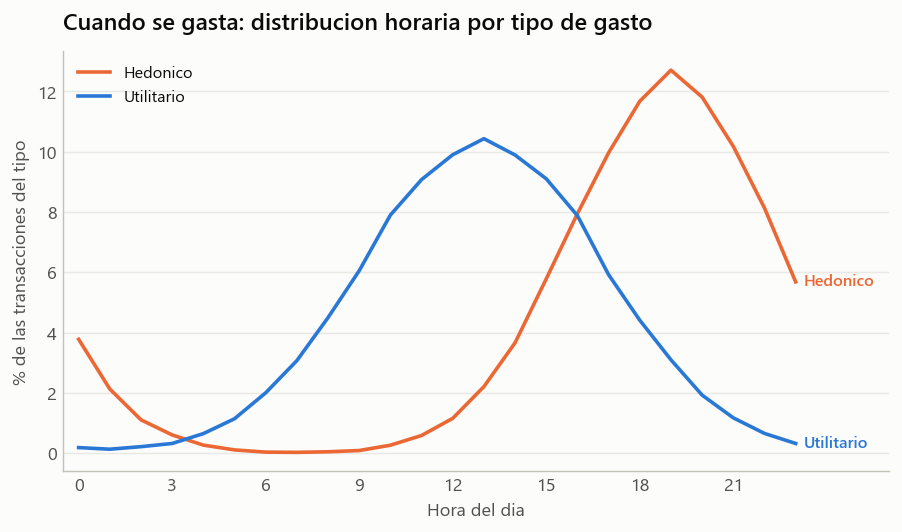

In [3]:
#| label: fig-horario
#| fig-cap: "Distribución horaria de las transacciones, por tipo de gasto."
viz.perfil_horario(df)
Image(str(cfg.FIGURES / "05_perfil_horario.png"))